# Classification of Heart Disease: Logistic Regression

## Contents

* **[Introduction](#introduction)**
  
  - [Aim](#aim)
  - [Dataset](#dataset)
  - [Data Dictionary](#data-dictionary)
  - [Important Features: Breakdown](#important-features-breakdown)

---

* **[Loading the Dataset](#loading-the-dataset)**

  - [Missing Data](#handling-missing-data)

---

* **[Train/Test Split and EDA](#traintest-split-and-exploratory-data-analysis)**

  - [Numeric Variable Distributions](#numeric-variable-distribution)
  - [Categorical Variable Distributions](#categorical-variable-distribution)
  - [Correlations](#correlations)

    * [Numeric Variables](#numeric-variables)
    * [Categorical Variables](#categorical-variables)
    * [Relevant Features](#relevant-features)

---

* **[Preprocessing](#preprocessing)**

---

* **[Model Fitting](#model-fitting)**

  - [Mathematical Representation of the Model](#mathematical-representation-of-the-model)
  - [Model Coefficient Interpretation](#model-coefficient-interpretation)

---

* **[Model Evaluation](#model-evaluation)**

  - [Accuracy](#accuracy)
  - [Confusion Matrix](#confusion-matrix)
  - [ROC Curve](#roc-curve)
  - [Probability Thresholds](#probability-thresholds)

---

* **[Summary](#summary)**

  

## Introduction 

*This project can be seen as an extension to the `kNN-model` project - please refer to this project for additional details.*

Cardiovascular diseases (CVDs) continue to represent the leading cause of mortality worldwide, according to an article published by the World Health Organization (WHO) in July 2025. In 2022 alone, approximately 19.8 million deaths were attributed to CVDs, accounting for around 32% of all global deaths.

Importantly, the majority of CVD cases are considered preventable through the management of behavioural and environmental risk factors, including tobacco use, unhealthy diet, obesity, air pollution, alcohol consumption and physical inactivity. This highlights the critical role of early intervention, enabling healthcare providers to identify at-risk individuals and support lifestyle changes that may reduce the likelihood of disease development.

In this context, predictive modelling presents a valuable opportunity to support clinical decision-making by identifying individuals at elevated risk. Machine learning techniques can be applied to patient data to develop classification models capable of predicting the likelihood of heart disease based on a range of personal and clinical features.

### Aim

The aim of this project is to develop a **logistic regression** binary classifier for heart disease prediction, primarily to improve upon the related k-NN heart classification model.

Advantages of employing logistic regression compared to k-NN:

* Logistic Regression is considerably more **interpretable** and allows us to assign probabilities to each classification result, which is of massive importance in medical applications.

* The ability to assign probabilities can allow us to tweak the threshold that the classifier will use to predict heart disease, providing additional flexibility (we can use this to minimize false negative predictions for example).

* It also offers the chance to potentially improve upon the accuracy of the k-NN implementation (which achieved ~85%) by using an alternative ML algorithm.

### Dataset

The analysis utilises the [UC Irvine Machine Learning Repository Heart Disease dataset](https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data), which contains clinical data from multiple hospitals, including the Cleveland dataset commonly used in machine learning studies. The dataset comprises approximately 300 patient records with 14 clinical features, including demographic, physiological, and diagnostic variables, alongside a multi-class target indicating both presence or absence of heart disease and severity of the diagnosis.

### Data Dictionary

| Column                      | Definition                                                                                                                        |
|-----------------------------|-----------------------------------------------------------------------------------------------------------------------------------|
| id                          | Unique identifier of the patient                                                                                                  |
| age                         | Age of patient (years)                                                                                                            |
| sex                         | Biological gender of patient                                                                                                      |
| dataset                     | Geographical origin of the patient (*e.g.,* Switzerland, Hungary, USA (Ohio/California))                                          |
| cp                          | Chest pain type (typical angina, atypical angina, non-anginal, asymptomatic)                                                                                                                                                     |
| trestbp                     | Resting blood pressure (mm Hg)                                                                                                    |
| chol                        | Serum cholesterol (mg/dL)                                                                                                         |
| fbs                         | Fasting blood sugar (True if fbs > 120 mg/dL (equiv. to 6.7 mmol/L), False otherwise)                                             |
| restecg                     | Resting electrocardiogram results (normal: Normal, st-t abnormality: ST-T wave abnormality [T wave inversions and/or ST elevation/depression > 0.05 mV], lv hypertrophy: showing probable or definite left ventricular hypertrophy by Estes' criteria)                                                                        |
| thalch                      | Maximum heart rate achieved during exercise test (bpm)                                                                            |
| exang                       | Exercise-induced angina (True/False)                                                                                              |
| oldpeak                     | ST-segment depression during exercise (mm)                                                                                        |
| slope                       | The slope of the peak exercise ST segment (Up: upsloping, Flat: flat, Down: downsloping)                                          |
| ca                          | Number of major blood vessels visible via fluoroscopy (0-3)                                                                       |
| thal                        | Thallium stress test result (normal/fixed defect/reversible defect)                                                               |
| num                         | Target variable (0: Normal, 1-4: Increasing severity of heart disease)                                                            |


### Important Features: Breakdown

**`age`**

Heart Disease risk increases with age:

* Arteries stiffen
* Plaque builds up over time

---

**`origin`**

Can introduce bias since different hospitals are different populations.
We can likely drop this.

---

**`sex`**

* Men generally have greater risk earlier in life
* Women’s risk increases post-menopause

---

**`cp`**

A key indicator of heart disease

Types:

* Typical angina - Classic heart-related chest pain, a known strong indicator of coronary artery disease
* Atypical angina - Some features of angina, but not classic
* Non-anginal pain - Likely not heart-related
* Asymptomatic - No pain but disease may still exist (dangerous)

---

**`trestbps`**

High blood pressure (Hypertension):
* Damages arteries
* Increases workload on heart

---

**`chol`**

High cholesterol:

* Can lead to plaque buildup (atherosclerosis)
* Narrows arteries: heart disease risk

As was demonstrated in the `kNN-model` project, total serum cholesterol can be an unreliable indicator of heart disease as it is specifically **Low-Density Lipoprotein, LDL** that is correlated with plaque build-up. Total serum cholesterol is a combination of HDL, LDL and triglycerides.

---

**`fbs`**

High fasting blood sugar:

* Indicates possible diabetes, which is a known major risk factor of heart disease.

It is not always a great predictor in isolation, but can be useful as an interaction term.

---

**`restecg`**

ECG measures electrical activity of the heart

Abnormalities can indicate:
* Poor blood flow
* Structural issues

---

**`thalach`**

A lower-than-expected max heart rate can signal heart problems. A rough prediction of a patient's expected maximum heart rate can be calculated with the Tanaka formula:

MaxHR $\approx$ 208 - (0.7 $\cdot$ Age) 

This formula was derived from large population studies by [Hirofumi Tanaka, *et al.* (2001)](https://www.jacc.org/doi/abs/10.1016/S0735-1097(00)01054-8)

Higher is generally better (to a point).

*It may be of interest to derive a new feature `max_hr_%` for each patient, comparing their measured `thalach` value to the predicted value using the patient's age.*

---

**`exang`**

If exercise causes chest pain, it can be an indicator of impaired coronary artery blood flow.

---

**`oldpeak`**

Larger values suggest reduced blood flow to the heart, which is a strong indicator of heart disease.

---

**`slope`**

Downsloping or flat ST slope during exercise has been correlated with an increased risk of heart disease.

---

**`ca`**

Values between 0-3, describing how many affected/compromised coronary arteries are visible via fluoroscopy.
 
Fluoroscopy is an X-ray imaging technique. In this context, it is used to visualize blood flow through coronary arteries.

If more damaged/blocked blood vessels are visible, this is indicates an increased risk of heart disease.

---

**`thal`**

Results of a Thallium stress test. A radioactive thallium tracer is injected into a patient, enabling blood flow to be imaged during rest and exercise.

* "Fixed defect" indicates past heart damage (permanent)
* "Reversible defect" indicates a current blood flow issue (temporary)

## Loading the Dataset

We can begin by exploring the dataset to become familiar with the dimensions, missing values, distributions *etc.*

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

plt.style.use('fivethirtyeight')

import warnings
warnings.filterwarnings('ignore')

heart_data = pd.read_csv("heart_disease_uci.csv")

In [2]:
heart_data.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
heart_data.shape

(920, 16)

The dataset contains 920 patient records with 14 features (excluding `id` and the target class label `num`).

In [4]:
heart_data.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='str')

All column names are formatted as expected. 

* `num` is not a very descriptive name for the target variable, so will be renamed to `priority`, since the target variable is essentially a multi-class label from 0 (no diagnosed heart disease) to 4 (increasing severity of heart disease diagnoses).

* `ca` is also poorly labelled, so will be renamed to `artery_count`.

In [5]:
heart_data.rename(columns={'num': 'priority', 'ca': 'artery_count'}, inplace=True)

In [6]:
heart_data.drop(columns=['id'], inplace=True) # drop redundant id column

In [7]:
heart_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           920 non-null    int64  
 1   sex           920 non-null    str    
 2   dataset       920 non-null    str    
 3   cp            920 non-null    str    
 4   trestbps      861 non-null    float64
 5   chol          890 non-null    float64
 6   fbs           830 non-null    object 
 7   restecg       918 non-null    str    
 8   thalch        865 non-null    float64
 9   exang         865 non-null    object 
 10  oldpeak       858 non-null    float64
 11  slope         611 non-null    str    
 12  artery_count  309 non-null    float64
 13  thal          434 non-null    str    
 14  priority      920 non-null    int64  
dtypes: float64(5), int64(2), object(2), str(6)
memory usage: 107.9+ KB


### Handling Missing Data

In [8]:
heart_data.isnull().sum()

age               0
sex               0
dataset           0
cp                0
trestbps         59
chol             30
fbs              90
restecg           2
thalch           55
exang            55
oldpeak          62
slope           309
artery_count    611
thal            486
priority          0
dtype: int64

In [9]:
heart_data["dataset"].value_counts()

dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64

A number of the features have missing values, some more extreme than others. Since this dataset is a collation of patient data from four separate hospitals based in:

* Cleveland, Ohio (USA)
* Hungary
* VA Long Beach, California (USA)
* Switzerland

It may be of interest to see if there is a pattern to the missing data:

In [10]:
grouped = heart_data.groupby("dataset")
missing = grouped.apply(lambda x: x.isnull().sum())
missing

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,artery_count,thal,priority
dataset,,,,,,,,,,,,,,
Cleveland,0,0,0,0,0,0,0,0,0,0,1,5,3,0
Hungary,0,0,0,1,23,8,1,1,1,0,189,290,265,0
Switzerland,0,0,0,2,0,75,1,1,1,6,17,118,52,0
VA Long Beach,0,0,0,56,7,7,0,53,53,56,102,198,166,0


This reveals the majority of missing values originate from the Long Beach, Hungary and Switzerland locations. The simplest thing to do in this case is use only the Cleveland dataset since it is the most complete. 

It would be unwise to try to impute the missing values from the other locations using the available data (since it is mostly all from the Cleveland location) as this will introduce bias. Also, is not sensible to try to impute specialized medical test results (fluoroscopy and thallium stress test results) - we would simply be undertaking guesswork which could seriously harm the reliability of the dataset.

We could potentially search for complete patient records from hospitals that are not Cleveland, however, this is **non-random** sampling, which could introduce bias unintentionally and harm sample representativeness from other hospitals. 

The safest thing to do in this case is to use only the Cleveland data and fill the missing values with a "missing" label. A missing label in medical diagnostic tests can actually be a signal itself as a missing test result can be indicative of other things: test was not ordered, results were clinically inconclusive, *etc.* which is informative - the model can learn from this.

In [11]:
cleveland = heart_data[heart_data["dataset"] == "Cleveland"]
cleveland.shape

(304, 15)

In [12]:
cleveland.isnull().sum()

age             0
sex             0
dataset         0
cp              0
trestbps        0
chol            0
fbs             0
restecg         0
thalch          0
exang           0
oldpeak         0
slope           1
artery_count    5
thal            3
priority        0
dtype: int64

We can handle this small number of missing values by labelling them as "missing". This way, we retain more data and do not drop potentially unique medical cases (since there may be good medical reason why these test results are missing).

In [13]:
cleveland[cleveland.isnull().any(axis=1)] # display rows with missing values

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,artery_count,thal,priority
87,53,Female,Cleveland,non-anginal,128.0,216.0,False,lv hypertrophy,115.0,False,0.0,upsloping,0.0,NaN,0
166,52,Male,Cleveland,non-anginal,138.0,223.0,False,normal,169.0,False,0.0,upsloping,NaN,normal,0
192,43,Male,Cleveland,asymptomatic,132.0,247.0,True,lv hypertrophy,143.0,True,0.1,flat,NaN,reversable defect,1
266,52,Male,Cleveland,asymptomatic,128.0,204.0,True,normal,156.0,True,1.0,flat,0.0,NaN,2
287,58,Male,Cleveland,atypical angina,125.0,220.0,False,normal,144.0,False,0.4,flat,NaN,reversable defect,0
302,38,Male,Cleveland,non-anginal,138.0,175.0,False,normal,173.0,False,0.0,upsloping,NaN,normal,0
303,28,Male,Cleveland,atypical angina,130.0,132.0,False,lv hypertrophy,185.0,False,0.0,NaN,NaN,NaN,0


Since the datatype of the `artery_count` column is an int, we must convert the column to a str type. This can be achieved through mapping:

In [14]:
mapping = {0.0: "0", 1.0: "1", 2.0: "2", 3.0: "3", np.nan: "missing"}

cleveland["artery_count"] = cleveland["artery_count"].map(mapping)

In [15]:
cleveland[cleveland.isnull().any(axis=1)] # show remaining rows with missing values

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,artery_count,thal,priority
87,53,Female,Cleveland,non-anginal,128.0,216.0,False,lv hypertrophy,115.0,False,0.0,upsloping,0,NaN,0
266,52,Male,Cleveland,asymptomatic,128.0,204.0,True,normal,156.0,True,1.0,flat,0,NaN,2
303,28,Male,Cleveland,atypical angina,130.0,132.0,False,lv hypertrophy,185.0,False,0.0,NaN,missing,NaN,0


In [16]:
cleveland.fillna("missing", inplace=True) # fill remaining missing values

cleveland.iloc[[87, 166, 192, 266, 287, 302, 303]] # show rows which had missing values to verify they are filled as intended

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,artery_count,thal,priority
87,53,Female,Cleveland,non-anginal,128.0,216.0,False,lv hypertrophy,115.0,False,0.0,upsloping,0,missing,0
166,52,Male,Cleveland,non-anginal,138.0,223.0,False,normal,169.0,False,0.0,upsloping,missing,normal,0
192,43,Male,Cleveland,asymptomatic,132.0,247.0,True,lv hypertrophy,143.0,True,0.1,flat,missing,reversable defect,1
266,52,Male,Cleveland,asymptomatic,128.0,204.0,True,normal,156.0,True,1.0,flat,0,missing,2
287,58,Male,Cleveland,atypical angina,125.0,220.0,False,normal,144.0,False,0.4,flat,missing,reversable defect,0
302,38,Male,Cleveland,non-anginal,138.0,175.0,False,normal,173.0,False,0.0,upsloping,missing,normal,0
303,28,Male,Cleveland,atypical angina,130.0,132.0,False,lv hypertrophy,185.0,False,0.0,missing,missing,missing,0


In [17]:
cleveland = cleveland.drop(columns=["dataset"]) # dataset column is redundant

In [18]:
cleveland.isnull().sum()

age             0
sex             0
cp              0
trestbps        0
chol            0
fbs             0
restecg         0
thalch          0
exang           0
oldpeak         0
slope           0
artery_count    0
thal            0
priority        0
dtype: int64

In [19]:
cleveland.drop_duplicates(inplace=True) # drop duplicate rows
cleveland.shape

(304, 14)

All missing data has been handled and the data has been checked for duplicates.

---

To simplify the classification task and make visualization simpler, we can convert the multi-class target `priority` into a binary-class target, `heart_disease`: 

>* `priority` values of zero indicate no heart disease, so will remain unchanged. 
>
>* `priority` values of 1, 2, 3 or 4 can be collapsed to a 1, indicating a positive diagnosis.

In [20]:
cleveland["heart_disease"] = cleveland["priority"].apply(lambda x: 0 if x == 0 else 1).astype(str) # cast to string for countplot visualization
cleveland.drop(columns=["priority"], inplace=True)
cleveland.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,artery_count,thal,heart_disease
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3,normal,1
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0,normal,0


`fbs` and `exang` also need to be cast as strings to be visualized correctly in countplots in the following section.

In [21]:
cleveland["fbs"] = cleveland["fbs"].apply(lambda x: 0 if x == False else 1).astype(str)
cleveland["exang"] = cleveland["exang"].apply(lambda x: 0 if x == False else 1).astype(str)

## Train/Test Split and EDA

After filtering and filling missing values, we can turn to performing some exploratory data analysis, including summary statistics, distribution visualization and identification of correlations between variables.

This is all done to further understand the patterns that exist in the dataset and to inform **feature selection**. The entire cleveland dataset will be used for the initial EDA. Technically, this is not fully correct as some data leakage from the test set will occur during EDA, however, this is not how features will be selected. The EDA conducted is simply to better understand the dataset as a whole and help inform understanding of the features that are ultimately selected in the model fitting stages.

>Note, the dataset will be split into training and testing sets at this stage to prevent data leakage. The testing data should not be able to influence any preprocessing stages.

Since the sample size is relatively small (~300), it is best to employ a train/test split with cross validation rather than a train/validation/test split. An 80/20 split will be used to maintain a sufficient number of training datapoints.

In [22]:
from sklearn.model_selection import train_test_split

X = cleveland.drop(columns=["heart_disease"])
y = cleveland["heart_disease"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

y_train.value_counts(), y_test.value_counts()

(heart_disease
 0    132
 1    111
 Name: count, dtype: int64,
 heart_disease
 0    33
 1    28
 Name: count, dtype: int64)

In [23]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((243, 13), (61, 13), (243,), (61,))

In [24]:
cleveland.describe()

,age,trestbps,chol,thalch,oldpeak
count,304.000000,304.000000,304.000000,304.000000,304.000000
mean,54.351974,131.684211,246.315789,149.723684,1.036184
std,9.150256,17.570949,52.108280,22.927263,1.160690
min,28.000000,94.000000,126.000000,71.000000,0.000000
25%,47.750000,120.000000,211.000000,133.750000,0.000000
50%,55.500000,130.000000,240.500000,153.000000,0.800000
75%,61.000000,140.000000,275.000000,166.000000,1.600000
max,77.000000,200.000000,564.000000,202.000000,6.200000


The ranges and measures of central tendency/spread all appear reasonable for the numeric variables.

In [25]:
cleveland.describe(include="str")

,sex,cp,fbs,restecg,exang,slope,artery_count,thal,heart_disease
count,304,304,304,304,304,304,304,304,304
unique,2,4,2,3,2,4,5,4,2
top,Male,asymptomatic,0,normal,0,upsloping,0,normal,0
freq,207,144,259,151,205,142,176,166,165


In [26]:
numerical_features = ["age", "trestbps", "chol", "thalch", "oldpeak"]
categorical_features = ["sex", "cp", "fbs", "exang", "restecg", "slope", "artery_count", "thal"]

### Numeric Variable Distribution

We can first look into the distribution of numeric variables.

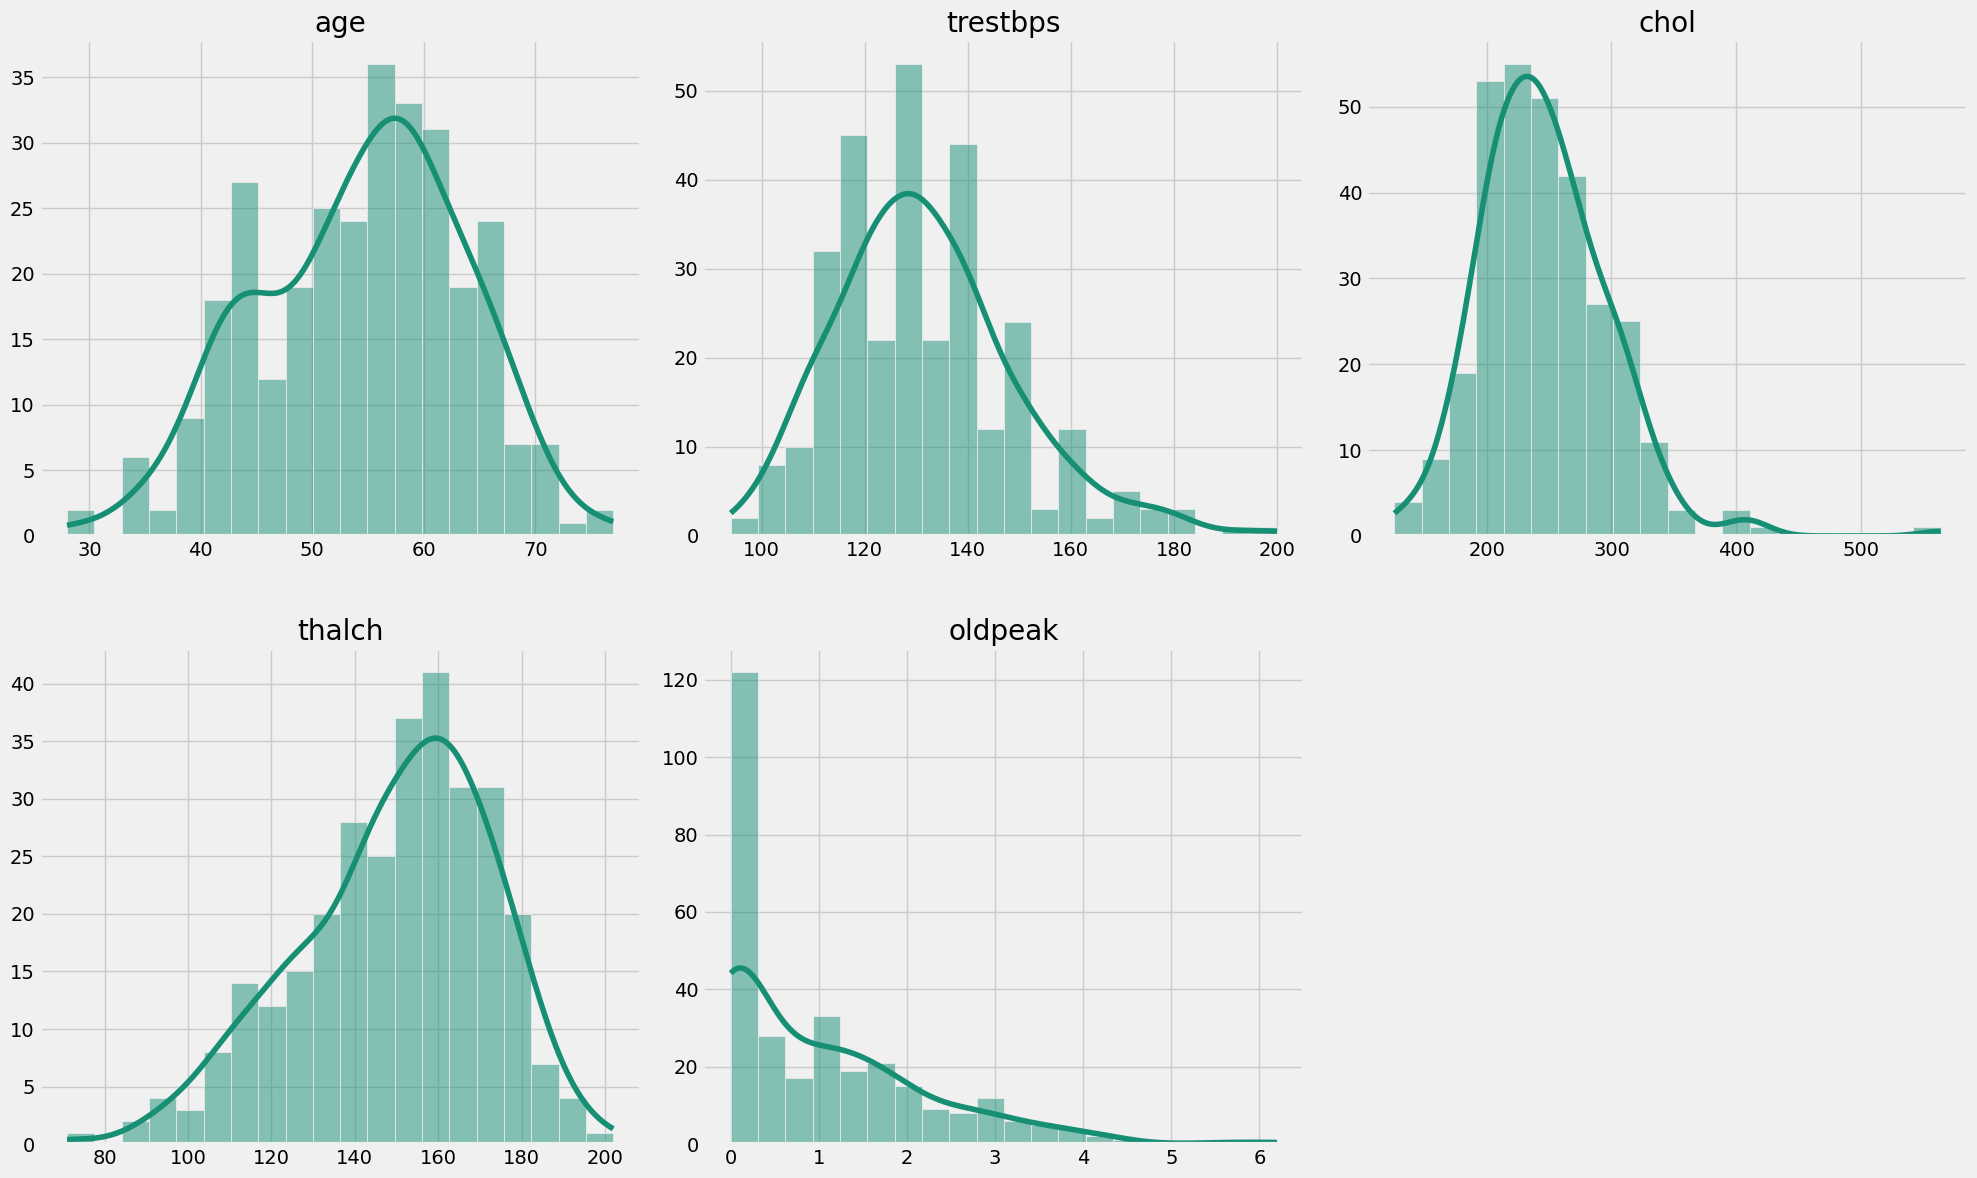

In [27]:
plt.figure(figsize=(20, 12))

for i, feature in enumerate(numerical_features):
    plt.subplot(2, 3, i+1)
    sns.histplot(cleveland[feature],
                 kde=True,
                 bins=20,
                 color="#178f75"
                 )
    plt.title(feature)
    plt.xlabel("")
    plt.ylabel("")

plt.tight_layout(h_pad=3)    
plt.show()

With the exception of `oldpeak`, all resemble a normal distribution.

* `thalch` (maximum observed heart rate during exercise) is slightly left skewed, meaning there are more observations at the upper end of the range.

* `oldpeak` is significantly right skewed - the majority of observations are at the low end of the range. This makes sense since deviations from 0 mm are indicative of abnormal heart function.

### Grouping by Target Variable

To get a better insight into how the distribution of each variable changes according to the target label, boxplots for each variable grouped by `heart_disease` are generated below.

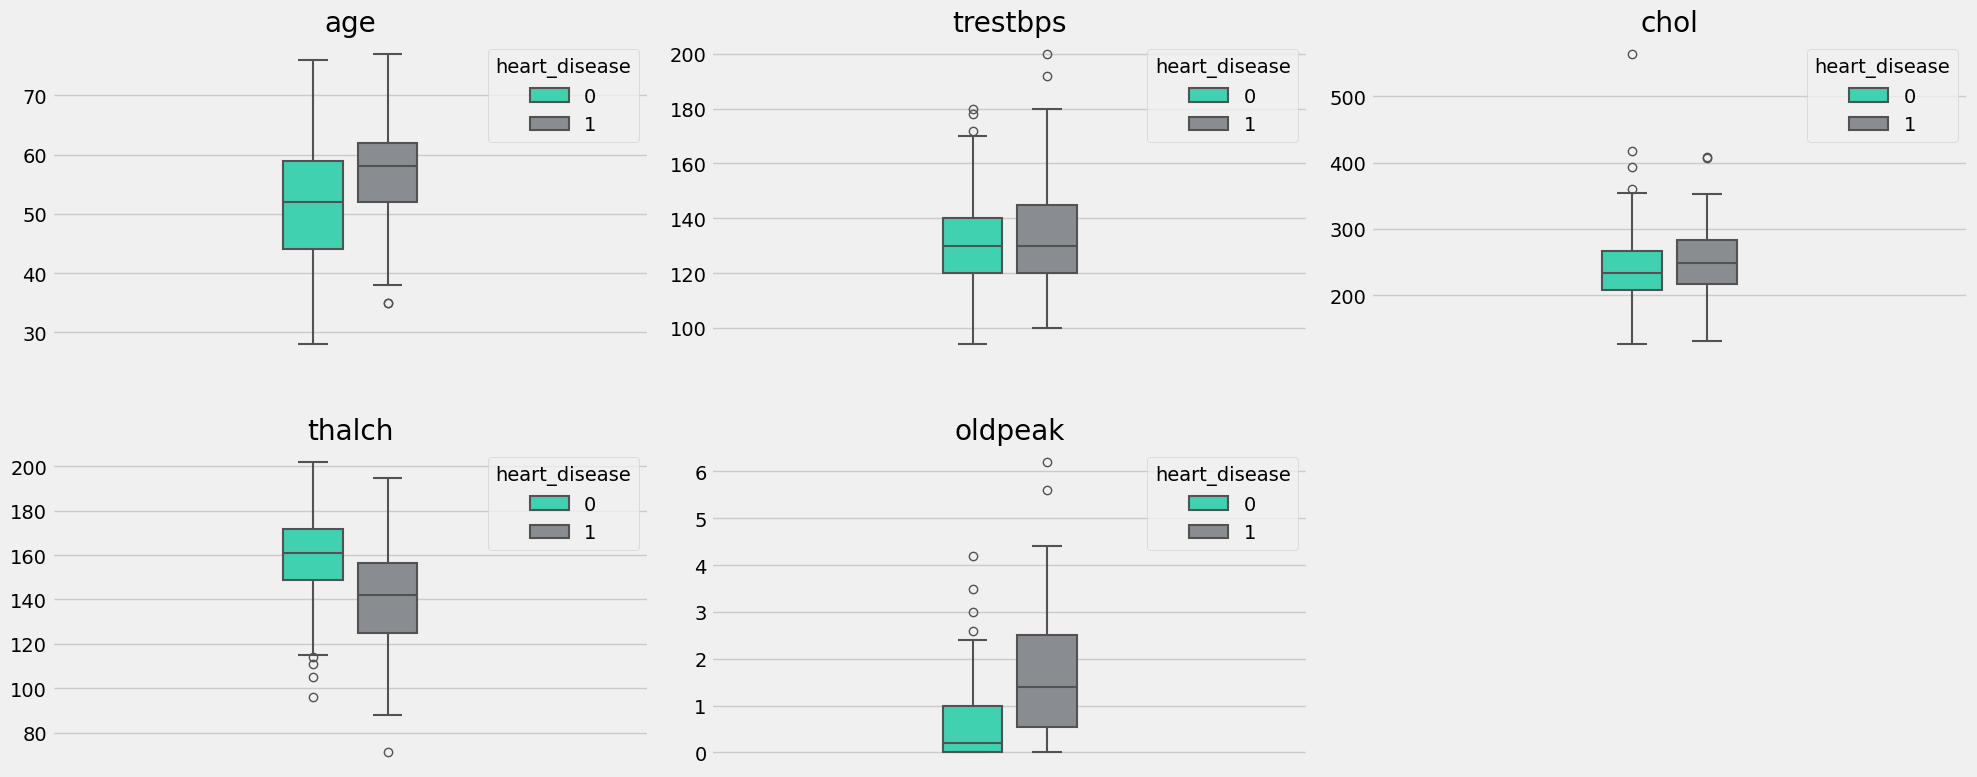

In [28]:
plt.figure(figsize=(20, 8))

for i, feature in enumerate(numerical_features):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=cleveland[feature],
                hue=cleveland["heart_disease"],
                width=0.25,
                linewidth=1.5,
                whis=1.5,
                gap=0.2,
                palette=["#28e9bf", "#888c92"]
                 )
    plt.title(feature)
    plt.xlabel("")
    plt.ylabel("")

plt.tight_layout(h_pad=3)    
plt.show()

### Key Observations

Patients diagnosed with heart disease are generally:

* Older

* Have greater resting blood pressure

* Have lower maximum heart rates during full effort exercise

* Have clear ST-T signal depression (`oldpeak` values greater than 0 mm)

### Categorical Variable Distribution

Next, we turn to verifying the distributions of the categorical variables.

In [29]:
categorical_features.append("heart_disease") # add binary class target variable to the list of categorical features for the visualization

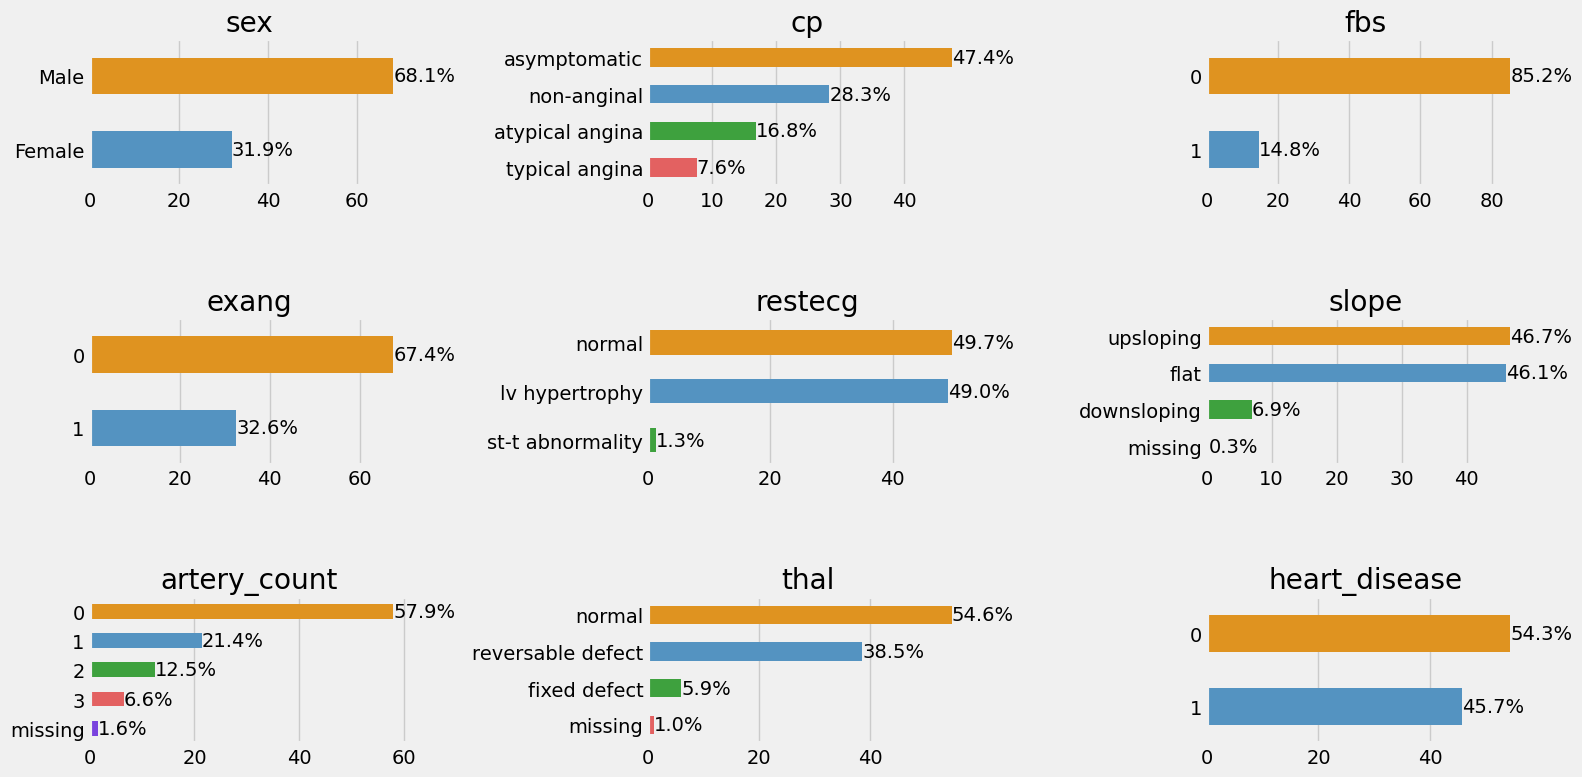

In [30]:
plt.figure(figsize=(16, 8))

for feature in categorical_features:
  ax = plt.subplot(3, 3, categorical_features.index(feature)+1)
  sns.countplot(cleveland[feature], 
                width=0.5, 
                stat="percent", 
                order=cleveland[feature].value_counts().index,
                palette=["#ff9900", "#4296d3", "#2eb12e", "#f84c4c", "#7229f8"]
                )
  plt.title(feature)
  plt.xlabel("")
  plt.ylabel("")
  
  for container in ax.containers:
    ax.bar_label(container, fmt="%1.1f%%", label_type="edge")
  
plt.tight_layout(h_pad=4)
plt.show()

#### Notable points

* Overall, 45.7% of the dataset has a positive label indicating heart disease. Therefore, there is *slight* imbalance in the class labels. The model may be slightly more biased towards predicting that a patient does not have heart disease - this should be considered and addressed if model performance is poor.

* As was true for the dataset used to train the k-NN model, we see gender imbalance in the patient data - 68.1% male.

* Asymptomatic chest pain is most predominant. Perhaps surprisingly, typical angina chest pain only comprises 7.6% of all cases.

* Patients with pre-diabetes/diabetes (indicated by a fasting blood sugar level exceeding 120 mg/dL) comprise of 14.8% of the dataset. 

* Just under a third of patient are diagnosed with exercise-induced angina.

* Just under 50% of patients in the dataset have normal ECG traces. Very few ST-T wave abnormalities represented in the dataset.

* Downsloping ST peak segments (within the `slope` feature) are under-represented in the dataset.

* 57.9% of cases do not show any defective arteries by fluoroscopy.

* 'fixed defect' results from the thallium stress test (`thal`) feature are considerably less well represented than 'reversable defects'.

#### Grouping by Target Variable

It is also of interest to group by the target variable to look for patterns in features which could indicate a greater likelihood of heart disease.

In [31]:
cleveland["heart_disease"] = cleveland["heart_disease"].astype(int) # class label back to int
categorical_features.remove("heart_disease") # remove binary class target variable as it is redundant for the visualization

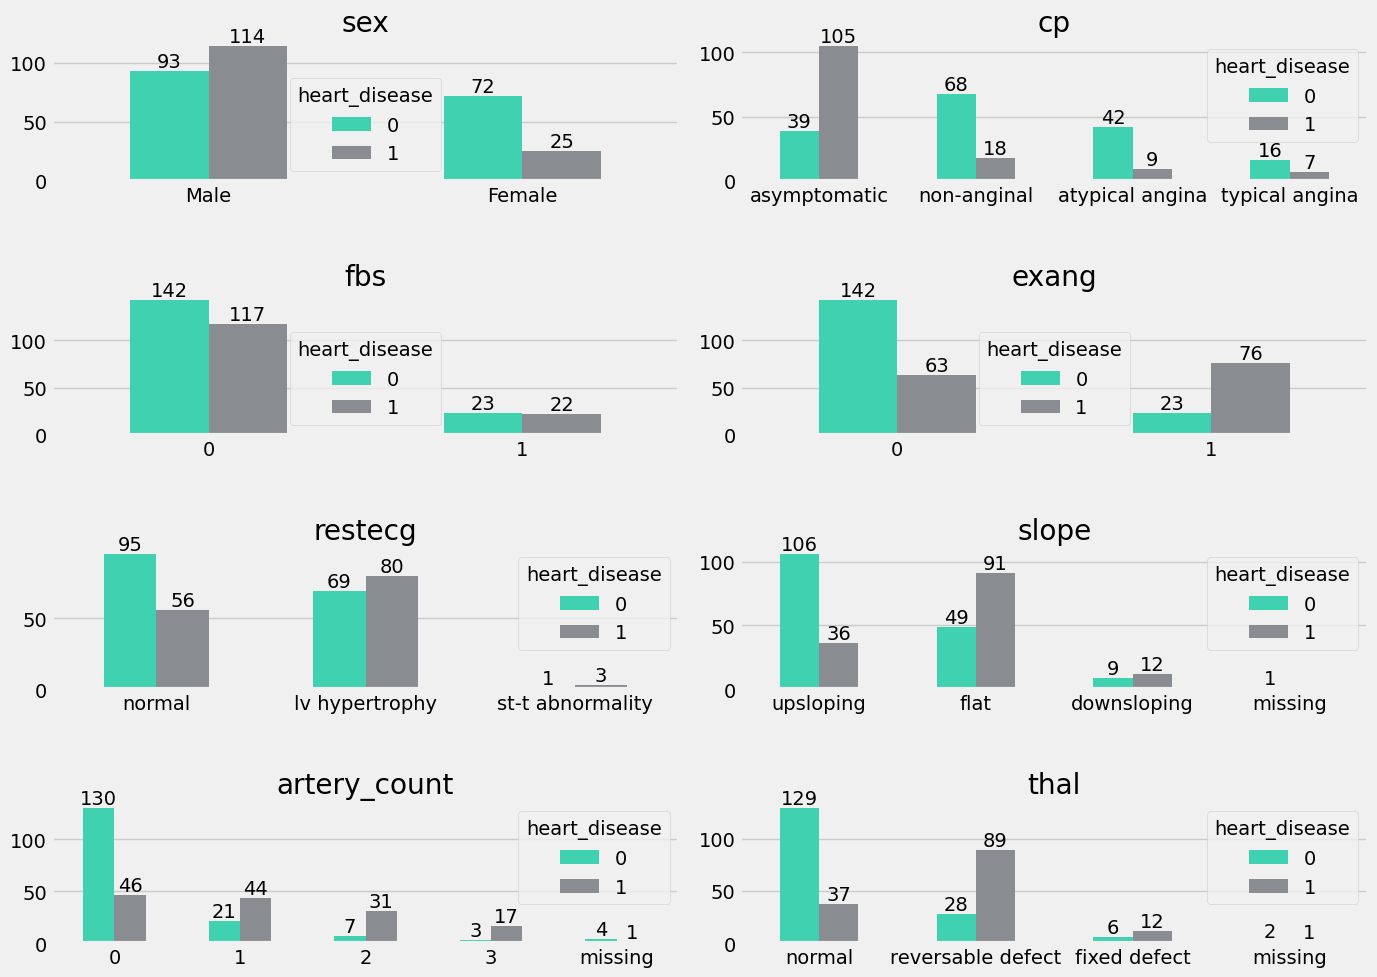

In [32]:
plt.figure(figsize=(14, 10))

for feature in categorical_features:
  ax = plt.subplot(4, 2, categorical_features.index(feature)+1)
  sns.countplot(x=cleveland[feature], 
                width=0.5, 
                stat="count", 
                order=cleveland[feature].value_counts().index,
                hue=cleveland["heart_disease"],
                palette=["#28e9bf", "#888c92"]
                )
  
  plt.title(feature)
  plt.ylabel("")
  plt.xlabel("")
  
  for container in ax.containers:
    ax.bar_label(container, label_type="edge")
  
plt.tight_layout(h_pad=3.0, w_pad=1.0)
plt.show()

### Key Observations

* A much greater proportion of males are diagnosed with heart disease than females. This supports the known relationship that males are at a greater risk of developing heart disease.

* Asymptomatic chest pain constitutes the greatest number of heart disease cases - this would suggest chest pain is not a particularly reliable indicator of heart disease.

* Fasting blood sugar alone is not a useful indicator of heart disease.

* Patients with exercise-induced angina look to be at a much greater risk of being diagnosed with heart disease.

* A significant number of cases with a "normal" ECG trace were diagnosed with heart disease, suggesting an ECG trace alone is insufficient as an indicator of heart disease. Similarly, many patients diagnosed with left ventricular hypertrophy (LVH) are not considered to have heart disease, further compounding the idea that ECG traces are insufficient standalone indicators.

* Patients with flat or downsloping ST-T peak signals are typically at greater risk of heart disease, since the majority of patients with these results are diagnosed with heart disease. This seems to be a more reliable indicator than others.

* Patients with visible coronary arteries (`artery_count`) during a fluoroscopy procedure seem to be at a much greater risk of being diagnosed with heart disease.

* Patients that are assessed to have reversable or fixed defects during a thallium stress test (`thal`) also seem to be at a much greater risk of being diagnosed.

## Correlations

### Numeric Variables

We can begin by looking at the correlation matrix of the numeric features with each other and the target variable.

In [33]:
numerical_features.append("heart_disease") # add binary class target variable to the list of numerical features for the visualization

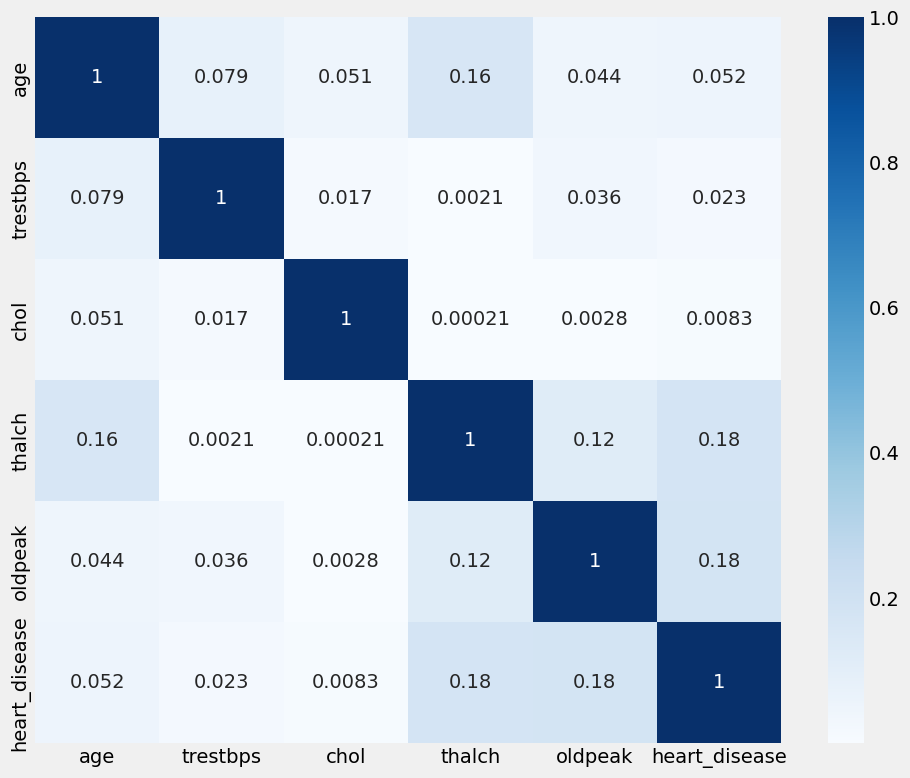

In [34]:
correlations = cleveland[numerical_features].corr()
r_squared = correlations**2 # R^2

plt.figure(figsize=(10, 8))

sns.heatmap(r_squared,
            cmap="Blues", 
            annot=True)

plt.tight_layout()
plt.show()

The above shows a heatmap of the coefficient of determination, $R^{2}$, calculated for each pair of variables in the `numerical_features` list. 

Below, we can filter the correlation matrix to show the stronger relationships. A "strong" linear relationship is arbitrarily chosen to be greater than 0.1, consistent with the previous kNN heart classifier model criteria.

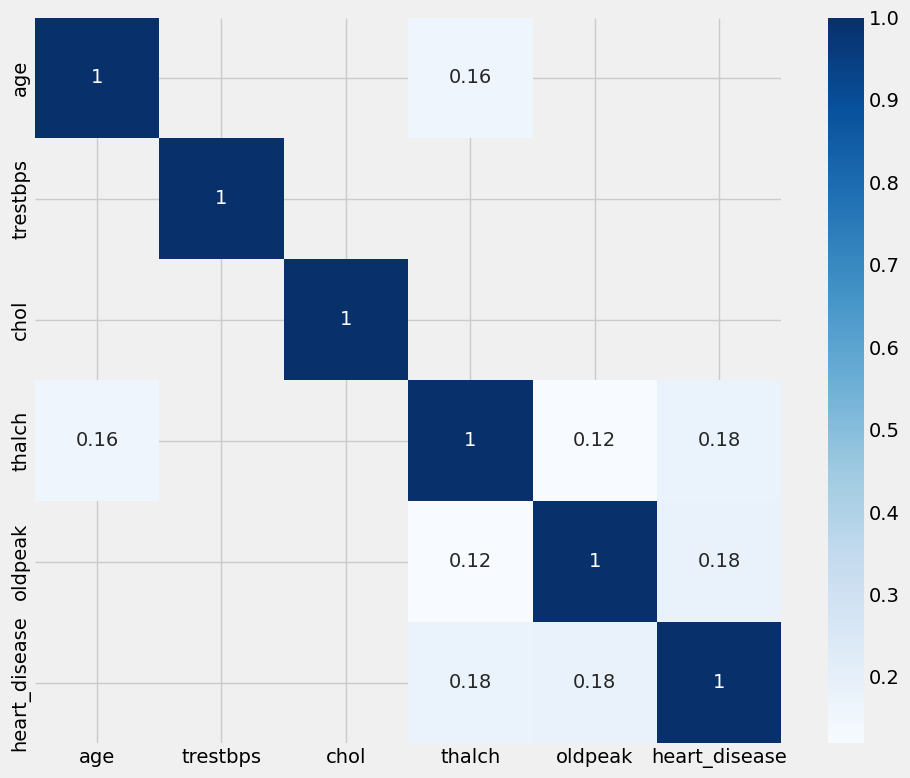

In [35]:
plt.figure(figsize=(10, 8))

sns.heatmap(r_squared[r_squared > 0.1],
            cmap="Blues", 
            annot=True)

plt.tight_layout()
plt.show()

The strongest linear relationships with the binary target variable, `heart_disease`, are observed for the follwing features:

* `thalch` (maximum HR achieved during exercise) 
* `oldpeak` (ST-T wave depression, in mm, measured from ECG data)

We can also identify evidence of co-linearity in this feature space since `thalch` shows some correlation with `age` and `oldpeak`. This may be problematic when implementing the logistic regression model since this can seriously affect the interpretability of model parameters. This will be considered during the feature selection process.

---

#### Deriving `max_hr_%`

Since it is apparent that the `thalch` variable is a good candidate for a model feature, it may be worth creating a further variable derived from the `thalch` data. 

This can be trialled in models to potentially improve predictive ability/enhance model interpretability.

The concept for this derived variable is to compare a patient's **expected** maximum heart rate (based on the patient's age) to the observed maximum heart rate achieved by the patient during maximum effort excerise (their `thalch` value).

One measure of expected maximum heart rate is given by:

>MaxHR $\approx$ 208 - (0.7 $\cdot$ Age) 
>
>*Source:* [Hirofumi Tanaka, *et al.* (2001)](https://www.jacc.org/doi/abs/10.1016/S0735-1097(00)01054-8)

max_hr_% can be defined as:

$$ \frac{thalch}{208 - (0.7 \cdot Age)} \cdot 100 $$


An example: a 40 year old patient's maximum heart rate was observed to be 155 bpm during vigorous exercise.

max_hr_% = $\frac{155}{208-(0.7\cdot40)}\cdot100$ = 86%, meaning this patients heart *may* be underperforming for their age - reaching only 86% of its potential.

Of course, this is only an approximation, but this derived measure is highly interpretable, which could be a great addition to a model for heart disease prediction.

In [36]:
cleveland["max_hr_%"] = ((cleveland["thalch"] / (208 - 0.7*cleveland["age"])) * 100).astype(int)

In [37]:
X_train["max_hr_%"] = ((X_train["thalch"] / (208 - 0.7*X_train["age"])) * 100).astype(int)
X_train.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,artery_count,thal,max_hr_%
68,59,Male,asymptomatic,170.0,326.0,0,lv hypertrophy,140.0,1,3.4,downsloping,0,reversable defect,83
208,55,Male,atypical angina,130.0,262.0,0,normal,155.0,0,0.0,upsloping,0,normal,91
167,54,Female,atypical angina,132.0,288.0,1,lv hypertrophy,159.0,1,0.0,upsloping,1,normal,93
105,54,Male,atypical angina,108.0,309.0,0,normal,156.0,0,0.0,upsloping,0,reversable defect,91
189,69,Male,non-anginal,140.0,254.0,0,lv hypertrophy,146.0,0,2.0,flat,3,reversable defect,91


In [38]:
X_test["max_hr_%"] = ((X_test["thalch"] / (208 - 0.7*X_test["age"])) * 100).astype(int) # repeat for test set
X_test.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,artery_count,thal,max_hr_%
219,59,Male,asymptomatic,138.0,271.0,0,lv hypertrophy,182.0,0,0.0,upsloping,0,normal,109
115,41,Male,atypical angina,135.0,203.0,0,normal,132.0,0,0.0,flat,0,fixed defect,73
295,41,Male,atypical angina,120.0,157.0,0,normal,182.0,0,0.0,upsloping,0,normal,101
87,53,Female,non-anginal,128.0,216.0,0,lv hypertrophy,115.0,0,0.0,upsloping,0,missing,67
279,58,Female,asymptomatic,130.0,197.0,0,normal,131.0,0,0.6,flat,0,normal,78


Checking correlations:

In [39]:
data = cleveland[["max_hr_%", "oldpeak", "thalch", "age", "heart_disease"]]

(data.corr())**2

,max_hr_%,oldpeak,thalch,age,heart_disease
max_hr_%,1.000000,0.100222,0.937042,0.026370,0.147248
oldpeak,0.100222,1.000000,0.119602,0.043779,0.181534
thalch,0.937042,0.119602,1.000000,0.161209,0.176080
age,0.026370,0.043779,0.161209,1.000000,0.052197
heart_disease,0.147248,0.181534,0.176080,0.052197,1.000000


We see a "strong" correlation between `max_hr_%` and `heart_disease`, aligned with the relationship observed between `thalch` and `heart_disease`.

As expected, `max_hr_%` and `thalch` are highly collinear. Specifically, over 93% of the variance in `max_hr_%` can be explained by `thalch`. This is entirely expected since `max_hr_%` is derived from `thalch`.

This could mean that models containing both `max_hr_%` and `thalch` as features could become difficult to interpret - it may be best to avoid including both features in the model as a result. Fortunately, since so much of the variance in one variable is explained by the other, it is likely redundant to include both features in one model anyway. 

### Categorical Variables

In order to determine the strength of any relationships between the categorical variables in the dataset, Cramér’s V can be used. This is an **initial screening method** to assess the strength of association between categorical predictors and the target variable. This can help eliminate predictors that are very weakly associated with the target.

Note that the final feature selection will be fine-tuned by evaluating the performance of regularised logistic regression models which can account for multivariate effects.

To calculate Cramér’s V for two categorical variables, a Chisquare test of association between the two variables must be conducted. The resulting Chisquare test statistic can then be used to find the Cramér’s V value to test for the strength of any association found from the Chisquare test.

Cramér’s V is given by the formula:

$$
V = \sqrt{\frac{\chi^{2}}{n \cdot min(r-1,c-1)}}
$$
where $\chi^{2}$ is the Chisquare test statistic, $n$ is the number of observations in the dataset and $r$, $c$ represent the number of rows and columns in the contingency table respectively. 

V will take a value between 0 and 1:

* $V = 0$ indicates no association between the variables

* $0 < V ≤ 0.1$ indicates a weak association

* $0.1 < V ≤ 0.3$ moderate association

* $0.3 < V ≤ 0.5$ strong association

* $V > 0.5$ very strong association

The function `cramers_v` from the custom module `correlation.py` is defined to do all of these steps, returning a formatted string containing the results of the Chisquare test and corresponding Cramér’s V value.

In [40]:
from correlation import cramers_v

In [41]:
categorical_features

['sex', 'cp', 'fbs', 'exang', 'restecg', 'slope', 'artery_count', 'thal']

In [42]:
for feature in categorical_features:
  print(cramers_v(cleveland[feature], cleveland["heart_disease"], cleveland))

sex vs heart_disease
  
    Chi-square statistic: 21.681712248608402
    p-value: 3.2184496609976774e-06
    Degrees of freedom: 1
    Cramér's V: 0.2671
    
cp vs heart_disease
  
    Chi-square statistic: 82.57477744876765
    p-value: 8.602916601728551e-18
    Degrees of freedom: 3
    Cramér's V: 0.5212
    
fbs vs heart_disease
  
    Chi-square statistic: 0.08979976519544859
    p-value: 0.7644318671680705
    Degrees of freedom: 1
    Cramér's V: 0.0172
    
exang vs heart_disease
  
    Chi-square statistic: 55.171058420884066
    p-value: 1.1048361290902256e-13
    Degrees of freedom: 1
    Cramér's V: 0.4260
    
restecg vs heart_disease
  
    Chi-square statistic: 9.732434339329167
    p-value: 0.007702447298357148
    Degrees of freedom: 2
    Cramér's V: 0.1789
    
slope vs heart_disease
  
    Chi-square statistic: 46.653185895402956
    p-value: 4.119047008105655e-10
    Degrees of freedom: 3
    Cramér's V: 0.3917
    
artery_count vs heart_disease
  
    Chi-square 

Cramér’s V analysis indicates fasting blood sugar (`fbs`) has a weak association with the target variable, while other categorical predictors demonstrate moderate to strong associations. This aligns with existing clinical understanding - fasting blood sugar is a primary indicator of diabetes rather than directly linking to heart disease.

We can consider dropping `fbs` entirely, but it may be that in combination with another predictor, it becomes useful at predicting heart disease. 

`restecg` is also on the lower end of the association strength scale, so this could be another candidate that may be less valuable. Nevertheless, it may be worth including in an initial model screen to verify.

---

It is also important to screen for collinearity between the categorical variables. To do this, a dataframe containing all unique cross-correlations can be constructed:

In [43]:
pd.options.display.max_rows = None
results = {}

for feature_one in categorical_features:
  for feature_two in categorical_features:
    results[feature_one + "_" + feature_two] = cramers_v(cleveland[feature_one], cleveland[feature_two], cleveland, v_only=True)
  
cross_correlations = pd.DataFrame.from_dict(results, orient="index").sort_values(by=0, ascending=False)
cross_correlations.rename(columns={0: "V"}, inplace=True)

# clean up by removing redundant rows
cross_correlations.drop(cross_correlations[cross_correlations["V"] > 0.98].index, inplace=True) # drop all leading diagonals
cross_correlations.drop_duplicates(subset=["V"], inplace=True) # drop duplicates

# some duplicates were not removed due to rounding error, so are manually removed
cross_correlations.drop(index=["exang_cp", "sex_thal", "artery_count_slope", "sex_cp", "restecg_slope", "sex_restecg"], inplace=True) 

cross_correlations

,V
cp_exang,0.467978
thal_sex,0.387457
thal_slope,0.386185
thal_exang,0.328177
exang_slope,0.290522
slope_artery_count,0.279816
artery_count_thal,0.215458
thal_cp,0.210981
exang_artery_count,0.207025
artery_count_cp,0.191911


This reveals the extent of multi-collinearity between the categorical predictors as many (~21 pairs of categorical predictors) show moderate to strong associations with each other. Care will need to be taken in the feature selection process to ensure the effects of multi-collinearity are mitigated. This is planned to be done by using a regularized model to reduce the effects of multi-collinearity and evaluating model performance to ensure appropriate features are included to produce a parsimonious model.

### Relevant Features

Feature selection aims to balance predictive performance with **interpretability**. Given the limited dataset size, a parsimonious model (a well-fitted model using as few features as possible) is ideal to bolster model interpretability and robustness. Overfitting should be avoided while retaining clinically relevant and interpretable features.

The entire feature space will be taken forward and reduced during the initial model fitting.

**Numeric**

* `oldpeak`
* `thalch` and `max_hr_%` (best to choose one of these rather than including both due to collinearity)
* `age` (weaker correlation relative to `oldpeak` and `thalch/max_hr_%`, however, domain expertise suggests it may be a useful predictor in combination with other predictors)
* `trestbps` (likely to be dropped due to poor association with target variable)
* `chol` (likely to be dropped due to poor association with target variable)

**Categorical**
* `sex`
* `cp`
* `fbs` (likely to be dropped due to weak association observed for the standalone predictor)
* `exang` 
* `restecg` (association to heart disease is relatively weak when compared with other predictors - this may be dropped)
* `slope`
* `artery_count` 
* `thal` 

Evaluation of regularized logistic regression model performance will help in establishing which features are redundant and/or reduce the accuracy/interpretability of the model.

## Preprocessing

Before the model can be trained, some work needs to be done to set up the features, including **one-hot encoding** categorical variables (by creating dummy variables) and normalizing the data.

Data will be normalized using the `StandardScaler` since the distributions of each of the numeric features are approximately normal.

`oldpeak` is the exception here due to heavy right skew. A log transform is not recommended here since this will complicate interpretability, which is key for this application. Instead, the `RobustScaler` can be used here since it uses median and IQR to scale the data, which will prevent the scaling from being distorted.

In [44]:
X_train.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,artery_count,thal,max_hr_%
68,59,Male,asymptomatic,170.0,326.0,0,lv hypertrophy,140.0,1,3.4,downsloping,0,reversable defect,83
208,55,Male,atypical angina,130.0,262.0,0,normal,155.0,0,0.0,upsloping,0,normal,91
167,54,Female,atypical angina,132.0,288.0,1,lv hypertrophy,159.0,1,0.0,upsloping,1,normal,93
105,54,Male,atypical angina,108.0,309.0,0,normal,156.0,0,0.0,upsloping,0,reversable defect,91
189,69,Male,non-anginal,140.0,254.0,0,lv hypertrophy,146.0,0,2.0,flat,3,reversable defect,91


In [45]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_train.head()

,age,trestbps,chol,thalch,oldpeak,max_hr_%,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,...,exang_1,slope_flat,slope_upsloping,artery_count_1,artery_count_2,artery_count_3,artery_count_missing,thal_missing,thal_normal,thal_reversable defect
68,59,170.0,326.0,140.0,3.4,83,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
208,55,130.0,262.0,155.0,0.0,91,True,True,False,False,...,False,False,True,False,False,False,False,False,True,False
167,54,132.0,288.0,159.0,0.0,93,False,True,False,False,...,True,False,True,True,False,False,False,False,True,False
105,54,108.0,309.0,156.0,0.0,91,True,True,False,False,...,False,False,True,False,False,False,False,False,False,True
189,69,140.0,254.0,146.0,2.0,91,True,False,True,False,...,False,True,False,False,False,True,False,False,False,True


In [46]:
from sklearn.preprocessing import StandardScaler, RobustScaler

standard_scaler = StandardScaler()
oldpeak_scaler = RobustScaler()

X_train["oldpeak"] = oldpeak_scaler.fit_transform(X_train[["oldpeak"]])

X_train[["thalch", "max_hr_%", "age", "chol", "trestbps"]] = standard_scaler.fit_transform(X_train[["thalch", "max_hr_%", "age", "chol", "trestbps"]])

X_train.head()

,age,trestbps,chol,thalch,oldpeak,max_hr_%,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,...,exang_1,slope_flat,slope_upsloping,artery_count_1,artery_count_2,artery_count_3,artery_count_missing,thal_missing,thal_normal,thal_reversable defect
68,0.509621,2.220951,1.436115,-0.434612,1.677419,-0.370291,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
208,0.064161,-0.061765,0.218713,0.225180,-0.516129,0.268437,True,True,False,False,...,False,False,True,False,False,False,False,False,True,False
167,-0.047204,0.052371,0.713282,0.401125,-0.516129,0.428119,False,True,False,False,...,True,False,True,True,False,False,False,False,True,False
105,-0.047204,-1.317259,1.112742,0.269166,-0.516129,0.268437,True,True,False,False,...,False,False,True,False,False,False,False,False,False,True
189,1.623272,0.508914,0.066538,-0.170695,0.774194,0.268437,True,False,True,False,...,False,True,False,False,False,True,False,False,False,True


In [47]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 243 entries, 68 to 224
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       243 non-null    float64
 1   trestbps                  243 non-null    float64
 2   chol                      243 non-null    float64
 3   thalch                    243 non-null    float64
 4   oldpeak                   243 non-null    float64
 5   max_hr_%                  243 non-null    float64
 6   sex_Male                  243 non-null    bool   
 7   cp_atypical angina        243 non-null    bool   
 8   cp_non-anginal            243 non-null    bool   
 9   cp_typical angina         243 non-null    bool   
 10  fbs_1                     243 non-null    bool   
 11  restecg_normal            243 non-null    bool   
 12  restecg_st-t abnormality  243 non-null    bool   
 13  exang_1                   243 non-null    bool   
 14  slope_flat               

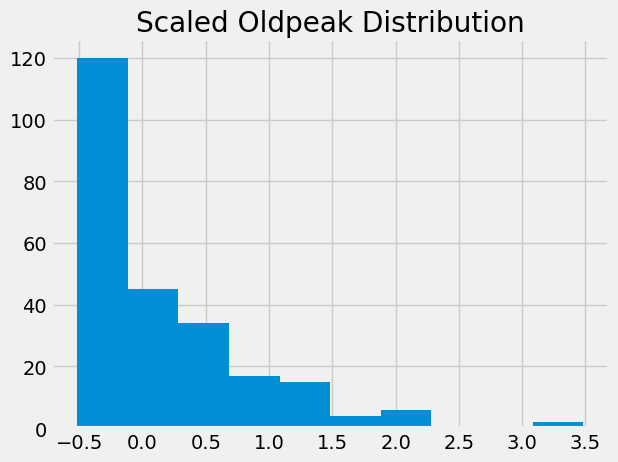

In [48]:
X_train["oldpeak"].plot.hist(legend=False)
plt.title("Scaled Oldpeak Distribution")
plt.ylabel("")

plt.show()

This is an improvement over the raw oldpeak data. Although skew still remains, the data is centered around 0 and the spread is more balanced around the median, reducing the influence of extreme values. It is also slightly better than what a standard scaler would provide as the standard scaler uses mean and standard deviation, which are more sensitive to extrema.

---

Repeating for the `thalch`, `max_hr_%` and `age` features, but with the standard scaler:

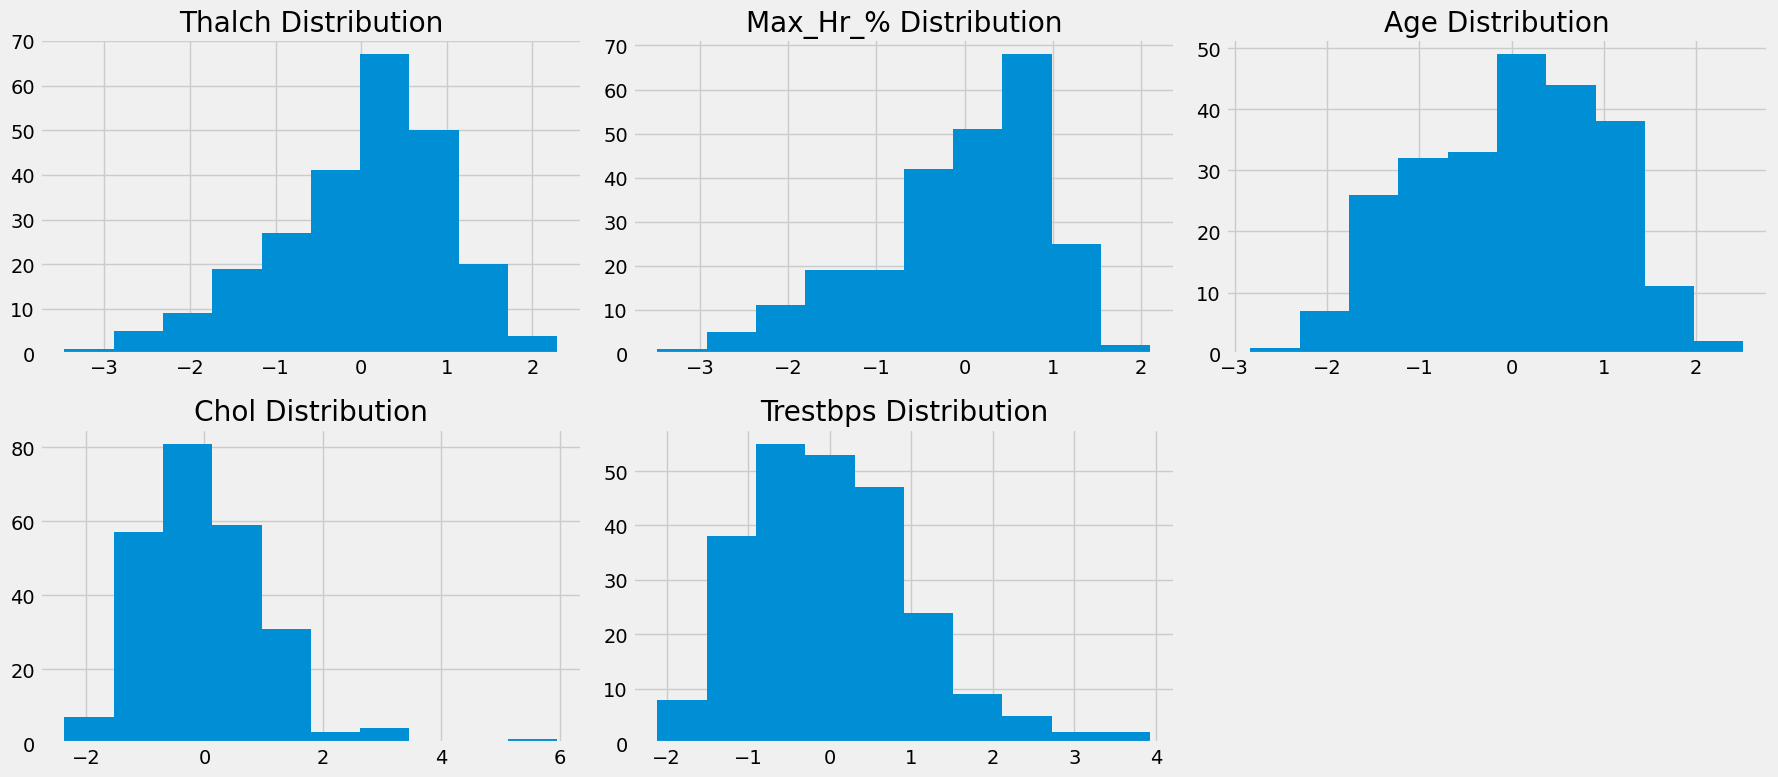

In [49]:
standard_train = X_train[["thalch", "max_hr_%", "age", "chol", "trestbps"]]

plt.figure(figsize=(18, 8))

for col in standard_train.columns:
  plt.subplot(2, 3, standard_train.columns.get_loc(col)+1)
  standard_train[col].plot.hist()
  plt.title(f"{col.title()} Distribution")
  plt.ylabel("")

plt.tight_layout()
plt.show()

This gives us the complete training feature space that can be further narrowed down during cross-validated training:

The same preprocessing can be applied to the test data:

In [50]:
X_test.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,artery_count,thal,max_hr_%
219,59,Male,asymptomatic,138.0,271.0,0,lv hypertrophy,182.0,0,0.0,upsloping,0,normal,109
115,41,Male,atypical angina,135.0,203.0,0,normal,132.0,0,0.0,flat,0,fixed defect,73
295,41,Male,atypical angina,120.0,157.0,0,normal,182.0,0,0.0,upsloping,0,normal,101
87,53,Female,non-anginal,128.0,216.0,0,lv hypertrophy,115.0,0,0.0,upsloping,0,missing,67
279,58,Female,asymptomatic,130.0,197.0,0,normal,131.0,0,0.6,flat,0,normal,78


In [51]:
X_test = pd.get_dummies(X_test, drop_first=True)

In [52]:
X_test["oldpeak"] = oldpeak_scaler.transform(X_test[["oldpeak"]])

X_test[["thalch", "max_hr_%", "age", "chol", "trestbps"]] = standard_scaler.transform(X_test[["thalch", "max_hr_%", "age", "chol", "trestbps"]])

X_test.head()

,age,trestbps,chol,thalch,oldpeak,max_hr_%,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,...,slope_flat,slope_missing,slope_upsloping,artery_count_1,artery_count_2,artery_count_3,artery_count_missing,thal_missing,thal_normal,thal_reversable defect
219,0.509621,0.394778,0.389910,1.412806,-0.516129,1.705575,True,False,False,False,...,False,False,True,False,False,False,False,False,True,False
115,-1.494950,0.223575,-0.903580,-0.786501,-0.516129,-1.168701,True,True,False,False,...,True,False,False,False,False,False,False,False,False,False
295,-1.494950,-0.632444,-1.778587,1.412806,-0.516129,1.066847,True,True,False,False,...,False,False,True,False,False,False,False,False,True,False
87,-0.158569,-0.175901,-0.656295,-1.534266,-0.516129,-1.647747,False,False,True,False,...,False,False,True,False,False,False,False,True,False,False
279,0.398256,-0.061765,-1.017711,-0.830488,-0.129032,-0.769496,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False


In [53]:
print(X_train.columns)
print("\n")
print(X_test.columns)

Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'max_hr_%', 'sex_Male',
       'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'fbs_1',
       'restecg_normal', 'restecg_st-t abnormality', 'exang_1', 'slope_flat',
       'slope_upsloping', 'artery_count_1', 'artery_count_2', 'artery_count_3',
       'artery_count_missing', 'thal_missing', 'thal_normal',
       'thal_reversable defect'],
      dtype='str')


Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'max_hr_%', 'sex_Male',
       'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'fbs_1',
       'restecg_normal', 'restecg_st-t abnormality', 'exang_1', 'slope_flat',
       'slope_missing', 'slope_upsloping', 'artery_count_1', 'artery_count_2',
       'artery_count_3', 'artery_count_missing', 'thal_missing', 'thal_normal',
       'thal_reversable defect'],
      dtype='str')


In [54]:
X_train["slope_missing"] = False # add slope_missing feature to train set to match test set

In [55]:
X_train = X_train.iloc[:, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 23, 15, 16, 17, 18, 19, 20, 21, 22]] # reorder columns to match test set

In [56]:
X_train.info() # verify train set

<class 'pandas.DataFrame'>
Index: 243 entries, 68 to 224
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       243 non-null    float64
 1   trestbps                  243 non-null    float64
 2   chol                      243 non-null    float64
 3   thalch                    243 non-null    float64
 4   oldpeak                   243 non-null    float64
 5   max_hr_%                  243 non-null    float64
 6   sex_Male                  243 non-null    bool   
 7   cp_atypical angina        243 non-null    bool   
 8   cp_non-anginal            243 non-null    bool   
 9   cp_typical angina         243 non-null    bool   
 10  fbs_1                     243 non-null    bool   
 11  restecg_normal            243 non-null    bool   
 12  restecg_st-t abnormality  243 non-null    bool   
 13  exang_1                   243 non-null    bool   
 14  slope_flat               

In [57]:
X_test.info() # verify test set

<class 'pandas.DataFrame'>
Index: 61 entries, 219 to 155
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       61 non-null     float64
 1   trestbps                  61 non-null     float64
 2   chol                      61 non-null     float64
 3   thalch                    61 non-null     float64
 4   oldpeak                   61 non-null     float64
 5   max_hr_%                  61 non-null     float64
 6   sex_Male                  61 non-null     bool   
 7   cp_atypical angina        61 non-null     bool   
 8   cp_non-anginal            61 non-null     bool   
 9   cp_typical angina         61 non-null     bool   
 10  fbs_1                     61 non-null     bool   
 11  restecg_normal            61 non-null     bool   
 12  restecg_st-t abnormality  61 non-null     bool   
 13  exang_1                   61 non-null     bool   
 14  slope_flat               

We can now move onto training models with this feature space.

## Model Fitting

Since model interpretability is key, an **L1 Regularized Logistic Regression** model is to be used (setting the `l1_ratio` hyperparameter to 1). This particular regularization approach has the advantage of learning feature importance in the presence of other features in the model. Coefficients are set to zero for redundant features and/or those which are not useful for model accuracy.

To fine tune the model, a cross-validated grid search will be used. Of note here is the hyperparameter `C`, which controls the strength of regularisation, acting as the inverse of the penalty applied to model coefficients. Smaller values of C (<1) increase regularisation, encouraging simpler models with smaller or zero-valued coefficients, while larger values reduce regularisation and allow more complex models.

The ROC-AUC (Area Under the Receiver Operator Characteristic Curve) scoring metric is to be used as the primary scoring metric during cross-validation due to its robustness and threshold-independent nature. Additional metrics, including F2 scores will be used to evaluate model performance on the test set to assess performance in a clinical setting.

The resulting best performing model can then be used to predict the test set class labels and real-world performance will be evaluated from there on.

In [58]:
from sklearn.linear_model import LogisticRegression

binary_classifier = LogisticRegression()

param_grid = {
  "C": [0.01, 0.05, 0.1, 0.25, 0.48, 0.485, 0.49, 0.5, 0.52, 1], # since we want an interpretable model, focus on smaller C values
  "l1_ratio": [1],
  "solver": ["liblinear"] # lbfgs is not recommended here since it does not support L1 regularization. liblinear is the best choice
}

In [59]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

grid = GridSearchCV(estimator=binary_classifier, 
                    param_grid=param_grid, 
                    cv=cv, 
                    n_jobs=-1, 
                    scoring="roc_auc",
                    verbose=1
                    )

grid.fit(X_train, y_train)

Fitting 10 folds for each of 10 candidates, totalling 100 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.05, ...], 'l1_ratio': [1], 'solver': ['liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : th

In [60]:
print(grid.best_params_)

{'C': 0.485, 'l1_ratio': 1, 'solver': 'liblinear'}


In [61]:
print(f"Best model ROC-AUC score: {grid.best_score_}")

Best model ROC-AUC score: 0.8843240093240092


In [62]:
binary_classifier = grid.best_estimator_

In [63]:
print(f"Accuracy of best model: {binary_classifier.score(X_train, y_train)}")

Accuracy of best model: 0.8353909465020576


In [64]:
model_coefficients = binary_classifier.coef_.tolist()[0]

binary_classifier.intercept_[0]

np.float64(0.0)

The intercept of the linear combination of predictors evaluated to zero.

In [65]:
features = X_train.columns.to_list()

for feature in features:
  print(f"{feature}: {binary_classifier.coef_[0][features.index(feature)]}")

age: 0.0
trestbps: 0.1468792799567106
chol: 0.07621782481473308
thalch: -0.4136072011456939
oldpeak: 0.3627006504674935
max_hr_%: 0.0
sex_Male: 0.6123453234843855
cp_atypical angina: -0.3614848213272791
cp_non-anginal: -1.0793940346638127
cp_typical angina: -0.79844875676121
fbs_1: 0.0
restecg_normal: -0.35734239504099435
restecg_st-t abnormality: 0.0
exang_1: 0.40147577510317933
slope_flat: 0.2751897099748649
slope_missing: 0.0
slope_upsloping: -0.1684112436562571
artery_count_1: 1.1286194133525251
artery_count_2: 1.0816861633963322
artery_count_3: 0.5337757155731863
artery_count_missing: 0.0
thal_missing: 0.0
thal_normal: -1.2358094856217468
thal_reversable defect: 0.22420830561961536


---

#### Mathematical Representation of the Model

A logistic regression model applies a mapping function to a linear combination of predictors, denoted by the intermediate variable $Z$. In particular, `LogisticRegression()` models use the sigmoid (aka logistic) function as the mapping function, essentially constraining the outcome to the range [0, 1].

The fitted model provides the coefficients, defining $Z$ as follows:

$Z = 0.15 \cdot restbp + 0.08 \cdot chol - 0.41 \cdot thalch + 0.36 \cdot oldpeak + 0.61 \cdot male - 0.36 \cdot ata - 1.08 \cdot na - 0.80 \cdot ta - 0.36 \cdot normalecg + 0.40 \cdot exang + 0.28 \cdot flatslope - 0.16 \cdot upslope + 1.13 \cdot oneartery + 1.08 \cdot twoartery + 0.53 \cdot threeartery - 1.23 \cdot normalthal + 0.23 \cdot reversablethal$

where $Z = \ln(\frac{E(heartdisease)}{1-E(heartdisease)})$

This means given a set of patient data, we can calculate the probability (expected value, `E(heartdisease)`) that the patient will be diagnosed with heart disease:

$$
E(heartdisease) = \frac{e^Z}{1+e^Z}
$$

This probability can be compared with a probability threshold built into the model to aid in diagnosis of heart disease. We can demonstrate this with the training data below. The value of $Z$ can be calculated for each observation, which is used to calculate the probability that the patient has heart disease. If this probability exceeds a set threshold value, the patient will be flagged as a case (assigned class label 1).

In [66]:
z = 0
for i in range(len(features)):
  component = X_train[features[i]] * binary_classifier.coef_[0][i]
  z += component

z = z + binary_classifier.intercept_[0]

data = pd.DataFrame({"z": z})

data["predicted_probability"] = data["z"].apply(lambda x: np.exp(x) / (1 + np.exp(x)))
data["predicted_class"] = data["predicted_probability"].apply(lambda x: 1 if x > 0.522425 else 0)
data["actual_class"] = y_train

data.head(10)

,z,predicted_probability,predicted_class,actual_class
68,2.461859,0.921424,1,1
208,-1.783441,0.143879,0,0
167,-0.526662,0.371296,0,0
105,-0.457882,0.387489,0,0
189,0.997347,0.730537,1,1
120,1.960832,0.876623,1,1
55,3.676285,0.975308,1,1
36,2.255182,0.905097,1,1
70,-2.579444,0.070473,0,0
272,3.177641,0.959984,1,1


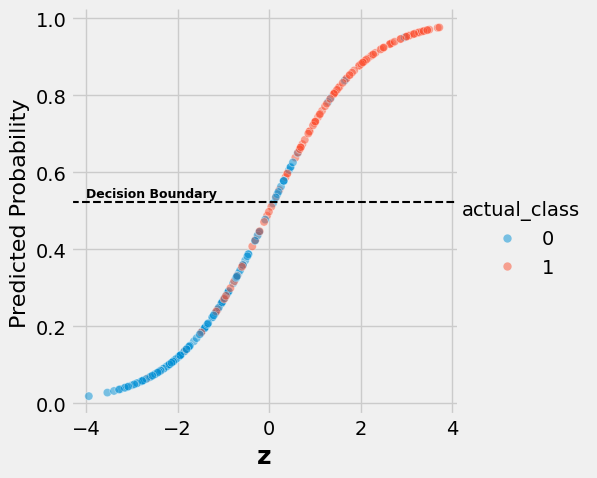

In [78]:
sns.relplot(data=data, 
            x="z", 
            y="predicted_probability",
            hue="actual_class",
            alpha=0.5,
            legend=True
            )

plt.axhline(y=0.522425, color="black", linestyle="--", linewidth=1.5)
plt.xlabel("z", size=18, weight="bold")
plt.ylabel("Predicted Probability", size=16)
plt.text(-4, 0.535, "Decision Boundary", size=9, weight="bold")

plt.show()

### Model Coefficient Interpretation

Before continuing on, it is of interest to interpret model coefficients as this can help with understanding. 

This can be achieved by **exponentiating** each of the coefficients to find the effect of a unit increase in the associated feature on the odds of having heart disease:

In [83]:
for feature in features:
  print(f"{feature}: {np.exp(binary_classifier.coef_[0][features.index(feature)])}")

age: 1.0
trestbps: 1.1582141349294908
chol: 1.0791976245790815
thalch: 0.6612606426821713
oldpeak: 1.4372055680257814
max_hr_%: 1.0
sex_Male: 1.8447528714073487
cp_atypical angina: 0.6966411700835702
cp_non-anginal: 0.3398013711231177
cp_typical angina: 0.4500265235370865
fbs_1: 1.0
restecg_normal: 0.6995329401155732
restecg_st-t abnormality: 1.0
exang_1: 1.4940279207193712
slope_flat: 1.3167804575612447
slope_missing: 1.0
slope_upsloping: 0.8450062597567427
artery_count_1: 3.091385626929088
artery_count_2: 2.949648950370669
artery_count_3: 1.7053591190630677
artery_count_missing: 1.0
thal_missing: 1.0
thal_normal: 0.2905994310709117
thal_reversable defect: 1.2513316516968878


Some examples: 

Holding all other predictors constant,

* A unit increase in resting blood pressure increases risk of heart disease by ~15.8%. Since this feature was standard scaled, a unit increase is equivalent to an increase of 1 standard deviation in the original unit scale (approximately 18 mmHg).

* A unit increase in maximum heart rate (thalch) **decreases** risk of heart disease by ~33.9%. Again, since this feature was standard scaled, a unit increase is equivalent to ~23 bpm in the original scale.

* If a patient has exercise induced angina, their risk of heart disease increases by ~49.4%.

This shows the power of logistic regression as a highly interpretable model, making it a great choice for clinical applications.

Perhaps the only confusing coefficients relate to the chest pain feature. Each of the symptomatic chest pain types (typical angina, atypical angina and non-anginal) correspond to a decreased risk of heart disease, which is clinically unexpected. This however makes sense when you consider the **majority** of the observations in the dataset have asymptomatic chest pain. The model has associated this with an increased risk of heart disease. Clearly, imbalance in this feature has led to an unintuative result in this case.

This would certainly be nice to address if taking this model forward. It would be beneficial to train the model on a dataset that is more balanced in this particular feature.

---

#### Selected Features

Feature selection was performed using L1-regularised logistic regression, which applies a penalty to the absolute magnitude of model coefficients. This encourages sparsity in the model by shrinking less informative feature coefficients to zero, thereby selecting a subset of the most relevant predictors while accounting for multivariate relationships between features.

In [68]:
features_and_coeffs = list(zip(features, model_coefficients))

chosen_features = []

for feature in features_and_coeffs:
  if abs(feature[1]) > 0:
    chosen_features.append(feature[0])

chosen_features

['trestbps',
 'chol',
 'thalch',
 'oldpeak',
 'sex_Male',
 'cp_atypical angina',
 'cp_non-anginal',
 'cp_typical angina',
 'restecg_normal',
 'exang_1',
 'slope_flat',
 'slope_upsloping',
 'artery_count_1',
 'artery_count_2',
 'artery_count_3',
 'thal_normal',
 'thal_reversable defect']

The chosen features are as follows:

* oldpeak
* thalch
* age
* sex
* cp
* fbs
* restecg
* slope
* artery_count
* thal

Note, this does not fully eliminate potential multi-collinearity from the model since there could still exist co-linear relationships in the reduced feature space.

## Model Evaluation

First, it is important to verify the test set has a roughly equal number of cases (class label 1) versus non-cases (class label 0):

In [69]:
y_test.value_counts()

heart_disease
0    33
1    28
Name: count, dtype: int64

### Accuracy

In [70]:
from sklearn.metrics import confusion_matrix, fbeta_score, roc_auc_score, roc_curve

predictions = binary_classifier.predict(X_test)

print(f"Accuracy: {binary_classifier.score(X_test, y_test)}")

Accuracy: 0.8524590163934426


The classifier achieves an 85.2% accuracy on the test set which is an excellent result, performing slightly better than typical reported performances for logistic regression on this dataset. This may reflect effective preprocessing and feature selection, though results may be influenced by dataset size and split variability.

Since we are aiming to predict disease, it is more appropriate to **minimize** false negatives. To evaluate the performance of the model, we can look to maximize the following metrics:

* Sensitivity (True Positive Rate) - given a patient has heart disease, what is the probability the model predicts the patient has heart disease?

* NPV (Negative Predictive Value) - given a negative prediction, what is the probability it is truly negative?

* F2 score (a combined measure of sensitivity and recall, placing **twice** as much emphasis on sensitivity)

All of these metrics and related metrics are scored from 0 to 1, with 1 being a perfect score. A confusion matrix can be used to calculate these metrics for more in-depth evaluation of the classifier's performance.

### Confusion Matrix

In [71]:
confusion_matrix = confusion_matrix(y_test, predictions, labels=[1, 0])

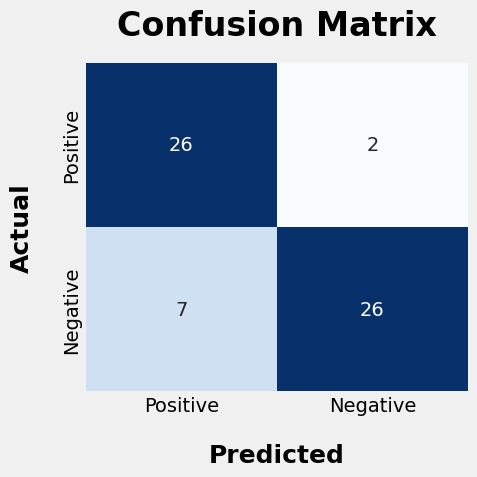

In [72]:
plt.figure(figsize=(5, 5))

sns.heatmap(confusion_matrix, annot=True, cbar=False, xticklabels=["Positive", "Negative"], yticklabels=["Positive", "Negative"], cmap="Blues") 
plt.title("Confusion Matrix", pad=20, weight="bold", size=24)
plt.xlabel("Predicted", size=18, weight="bold", labelpad=20)
plt.ylabel("Actual", size=18, weight="bold", labelpad=20)

plt.tight_layout()
plt.show()

In [73]:
sensitivity = confusion_matrix[0][0] / (confusion_matrix[0][0] + confusion_matrix[0][1]) # recall score
specificity = confusion_matrix[1][1] / (confusion_matrix[1][0] + confusion_matrix[1][1]) 

ppv = confusion_matrix[0][0] / (confusion_matrix[0][0] + confusion_matrix[1][0]) # positive predictive value (precision score)
npv = confusion_matrix[1][1] / (confusion_matrix[0][1] + confusion_matrix[1][1]) # negative predictive value

fnr = confusion_matrix[0][1] / (confusion_matrix[0][0] + confusion_matrix[0][1]) # false negative rate
fpr = confusion_matrix[1][0] / (confusion_matrix[1][0] + confusion_matrix[1][1]) # false positive rate

print(f"""
Sensitivity (Recall): {sensitivity:2f}
Specificity: {specificity:2f}
--------------------------------
PPV (Precision): {ppv:2f}
NPV: {npv:2f}
--------------------------------
FNR: {fnr:2f}
FPR: {fpr:2f}
--------------------------------
F1 Score: {fbeta_score(y_test, predictions, pos_label=1, beta=1):2f}
F2 Score: {fbeta_score(y_test, predictions, pos_label=1, beta=2):2f}
""")


Sensitivity (Recall): 0.928571
Specificity: 0.787879
--------------------------------
PPV (Precision): 0.787879
NPV: 0.928571
--------------------------------
FNR: 0.071429
FPR: 0.212121
--------------------------------
F1 Score: 0.852459
F2 Score: 0.896552



Sensitivity and FNR are notably better than the related to Specificity and FPR metrics, meaning the model is better tuned to minimise false negatives. This is ideal for a heart disease classifier, so this is a great result.

Overall, the F2 score for the logistic regression model is 0.897, a strong score which is weighted more towards sensitivity. This outperforms the k-NN model, which had an F2 score of 0.883.

### ROC Curve

A Receiver Operating Characteristic (ROC) curve is a graph that illustrates the performance of a binary classification model at all classification thresholds. The ROC curve is the plot of Sensitivity (True Positive Rate) vs. 1 - Sensitivity (False Positive Rate). A perfect classifier hugs the top left corner of the plot (TPR = 1, FPR = 0), indicating 100% Specificity and 100% Sensitivity. 

The $45^{o}$ diagonal line represents random guessing - a model that makes predictions by random chance. 

Each vertex (point) on the curve represents a different threshold. This is a probability value that, if exceeded, will cause the model to classify an observation as a case (class label 1). Adjusting the threshold by making it lower will make the model more sensitive (more true positives) at the expense of specificity (more false positives).

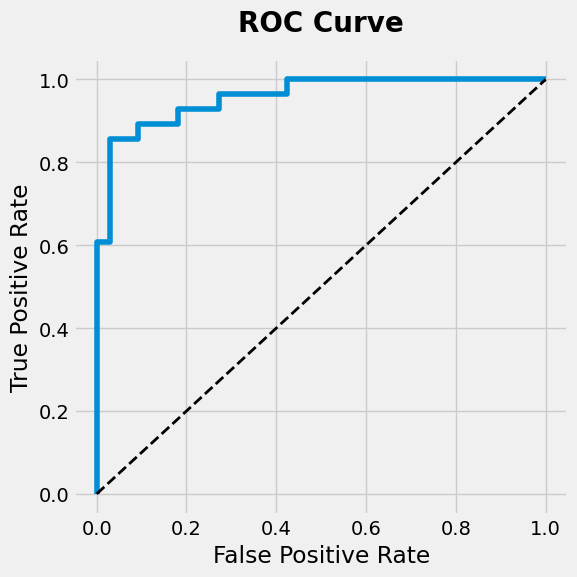

In [ ]:
y_prob = binary_classifier.predict_proba(X_test)[:, 1]

y_test = y_test.astype(int)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 6))

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], "--", color="black", linewidth=2) # add random guessing line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve", pad=20, weight="bold", size=20)

plt.tight_layout()
plt.show()

The area under the ROC curve (AUC) is a single scalar value between 0 and 1 which can be used to summarise the performance of a binary classifier. It is a measure of the probability that the model ranks a random positive case higher than a random negative case.

The random guessing line has an AUC score of 0.5, meaning any models with an AUC score of 0.5 or below are no better than random guessing. The strongest models lie in the range of 0.9-1.

In [75]:
print(roc_auc_score(y_test, y_prob))

0.9577922077922078


The AUC score for the logistic regression model comes in at 0.958, which is outstanding. This means the logistic regression model is well suited to this particular classification task and is able to distinguish between the two class labels well, independent of the probability threshold.

This is a clear improvement over the k-NN model, which had an AUC score of 0.930, implying the logistic regression model is a better classifier for this task.

### Probability Thresholds

The logistic regression model uses a probability value as a threshold to classify an observation into one of the two classes. For example, if the threshold is 0.6, any observation that the model is over 60% confident in being a case (class label 1) will be classified as such.

As mentioned above, each vertex on the ROC curve corresponds to a different probability threshold.

We can extract this information:

In [76]:
threshold_dict = {}

for i in range (0, len(thresholds)):
  threshold_dict[thresholds[i]] = (fpr[i], tpr[i])
  
threshold_df = pd.DataFrame.from_dict(threshold_dict, orient="index", columns=["False Positive Rate", "True Positive Rate"])

threshold_df["Quality"] = round(threshold_df["True Positive Rate"] - threshold_df["False Positive Rate"], 3)

threshold_df

,False Positive Rate,True Positive Rate,Quality
inf,0.000000,0.000000,0.000
0.963503,0.000000,0.035714,0.036
0.801903,0.000000,0.607143,0.607
0.772212,0.030303,0.607143,0.577
0.623405,0.030303,0.857143,0.827
0.616812,0.090909,0.857143,0.766
0.602788,0.090909,0.892857,0.802
0.538538,0.181818,0.892857,0.711
0.522022,0.181818,0.928571,0.747
0.409176,0.272727,0.928571,0.656


In [77]:
threshold_df.shape[0]

14

Each of the 14 rows correspond to a distinct confusion matrix constructed from the test set, achieved by varying the probability threshold of the binary classifer model. This threshold value is the index of each row.

This offers further tunability of the logistic regression model. For example, by setting the threshold to 0.605378, the classifier's FPR and TPR become 0.090909 and 0.892857 respectively. Depending on how tolerant we are of false negatives, we can adjust the probability threshold accordingly.

For the trained model evaluated above, the threshold is set at 0.522425 - sensitivity is more heavily weighted. This gives a high TPR 0.928571, meaning ~93% of the patients in the test set with heart disease are correctly classified by the model. 

If we wanted to adjust the model such that it produced fewer false positives, we could raise the threshold to 0.605378, though this would slightly increase the number of false negatives (TPR would become 0.892857). Typically, this is less desirable in clinical applications, where false negatives are more costly than false positives.

## Summary

A logistic regression model for heart disease prediction was developed, achieving a 83.5% accuracy on the cross-validated training data and a 85.2% accuracy on the test set. The similarity of the two accuracy metrics suggest the model is fitted appropriately and is generalising well to unseen data. The slight elevation in test accuracy can be attributed to the relatively small test set size, which is likely attributing to some variability.

The model performed exceptionally well, rivalling the best logistic regression models that have been trained on the UCI Cleveland heart disease dataset which may be a consequence of careful feature selection and preprocessing steps, though some variability is expected due to the smaller dataset size. 

An ROC AUC score of 0.958 was noted for the model, which is outstanding and out performs the k-NN model (with AUC score = 0.930) trained for the same purpose of predicting heart disease. Additionally, the model was shown to value sensitivity (0.929) more strongly than specificity (0.788), which is far more desirable for medical applications (also demonstrated by the strong F2 metric, 0.897).

The tuneability, interpretability and general performance outclasses the k-NN model, making it a clear choice for aiding in diagnosis of heart disease in a clinical setting.